### Post Generator for Social Platform

In [47]:
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START,END
from typing import TypedDict,Literal,Annotated
from pydantic import BaseModel, Field
from dotenv import load_dotenv
load_dotenv()
import os
import operator

In [48]:
groq_api = os.getenv("GROQ_API_KEY")
print(groq_api)

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


In [49]:
generator_llm = ChatGroq(groq_api_key=groq_api, model="llama-3.3-70b-versatile")
evaluator_llm = ChatGroq(groq_api_key=groq_api, model="llama-3.3-70b-versatile")
optimizer_llm = ChatGroq(groq_api_key=groq_api, model="llama-3.3-70b-versatile")

In [50]:
class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(...,description="Final evaluation result.")
    feedback: str = Field(...,description="feedback for the tweet.")

In [51]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [52]:
#defining state class
class TweetState(TypedDict):
    topic:str
    tweet:str
    evaluation: Literal["approved","needs_improvement"]
    feedback:str
    iteration:int
    max_iteration:int

    tweet_history:Annotated[list[str],operator.add]
    feedback_history:Annotated[list[str],operator.add]

In [53]:
def post_generator(state:TweetState):
    
    #prompt
    message=messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    #invoke
    response = generator_llm.invoke(message)

    return {"tweet":response.content,"tweet_history":[response.content]}

In [54]:
def evaluate_post(state: TweetState):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {"evaluation":response.evaluation,'feedback': response.feedback,"feedback_history":[response.feedback]}


In [55]:
def optimize_post(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {"response":response , "iteration":iteration ,"tweet_history":[response]}

In [56]:
#evaluation function
def route_evaluation(state:TweetState) -> Literal["approved",'needs_improvement']:
    if state['evaluation']=="approved" or state['iteration']>=state['max_iteration']:
        return "approved"
    else:
        return "needs_improvement"

In [57]:
graph = StateGraph(TweetState)

#defining nodes
graph.add_node("post_generator",post_generator)
graph.add_node("evaluate_post",evaluate_post)
graph.add_node("optimize_post",optimize_post)

#defining edges
graph.add_edge(START,"post_generator")
graph.add_edge("post_generator","evaluate_post")
graph.add_conditional_edges("evaluate_post",route_evaluation,{'approved':END,"needs_improvement":"optimize_post"})
graph.add_edge("optimize_post","evaluate_post")

In [58]:
workflow=graph.compile()

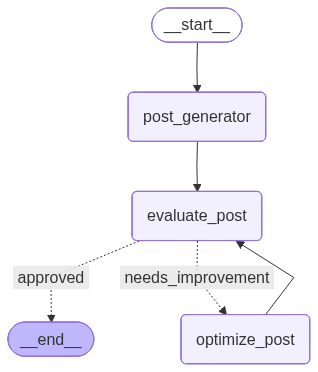

In [59]:
workflow

In [68]:
initial_state = {
    "topic":"123442dd",
    "iteration":1,
    "max_iteration":5
}

In [69]:
workflow.invoke(initial_state)

{'topic': '123442dd',
 'tweet': "just spent 10 mins typing '123442dd' and i'm still not sure what i'm unlocking, my future or a excel password",
 'evaluation': 'approved',
 'feedback': "This tweet is a breath of fresh air, offering a unique blend of relatability and absurdity. The humor is spot on, as the idea of spending 10 minutes typing a password only to question its purpose is both ridiculous and familiar. The tweet's punchiness is also commendable, being short and scroll-stopping. The format is well-executed, avoiding common pitfalls like setup-punchline jokes and question-answer formats. The only potential weakness is that the tweet's virality potential might be somewhat niche, but overall, it's a well-crafted tweet that deserves approval.",
 'iteration': 1,
 'max_iteration': 5,
 'tweet_history': ["just spent 10 mins typing '123442dd' and i'm still not sure what i'm unlocking, my future or a excel password"],
 'feedback_history': ["This tweet is a breath of fresh air, offering a